In [31]:
%load_ext autoreload
%autoreload 2
import math

import pandas as pd



from src.service.util import Util
from src.service.Statistics_measure.statistics_test import StatTest
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats



dataset = pd.read_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/credit_risk_cleansed_inunivariate_analysis_v0.csv')
util = Util(dataset,'loan_status')
stat_test = StatTest(dataset,'loan_status')

dataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_age,log_person_income
0,OWN,5.0,EDUCATION,B,1000,11.14,0,0.100000,N,2,3.044522,9.169518
1,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.570000,N,3,3.218876,9.169518
2,RENT,4.0,MEDICAL,C,35000,15.23,1,0.530000,N,2,3.135494,11.089805
3,RENT,8.0,MEDICAL,C,35000,14.27,1,0.643382,Y,4,3.178054,10.904119
4,OWN,2.0,VENTURE,A,2500,7.14,1,0.250000,N,2,3.044522,9.200290
...,...,...,...,...,...,...,...,...,...,...,...,...
31828,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.110000,N,30,4.043051,10.878047
31829,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.150000,N,19,3.988984,11.695247
31830,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.460000,N,28,4.174387,11.238489
31831,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.100000,N,26,4.025352,11.918391


______________

LOAN_INT_RATE :

            Question:
            - quel est la moyene des taux d'interte applique a une classe de population
            - pour une classe de taux [Petit, moyen , moyen-haut , haut ] , quel est le pourcentage de defaut ?         (localisation )



proportion des observation suivant les type de taux d'interet

        - observation de la distribution

In [32]:
discretise_ =  util.qcut('loan_int_rate')[0]['loan_int_rate_TRANCHE']
discretise_.value_counts()/dataset.shape[0]

loan_int_rate_TRANCHE
MOYEN     0.293281
FAIBLE    0.259322
FORT      0.249113
HAUT      0.198285
Name: count, dtype: float64

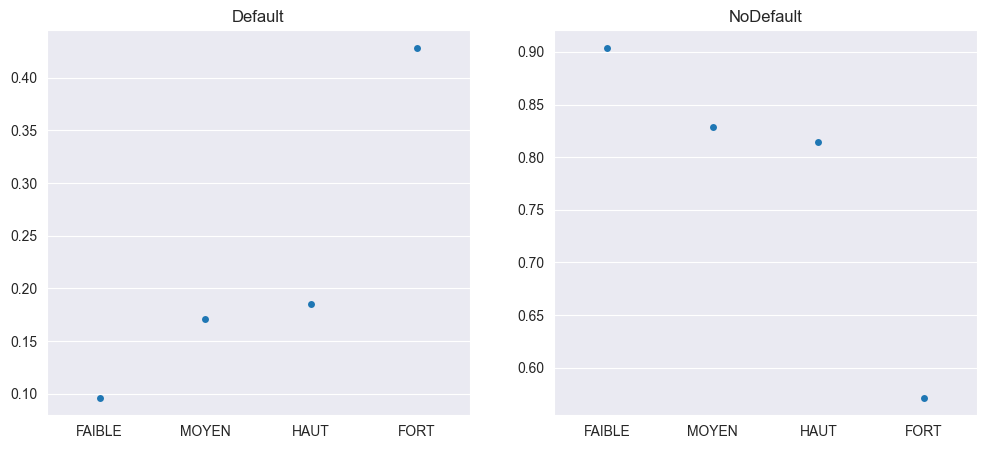

In [33]:
util.scatter_of_default_qtl('loan_int_rate')


        proportion des status de defaut pour les types de taux d'interet

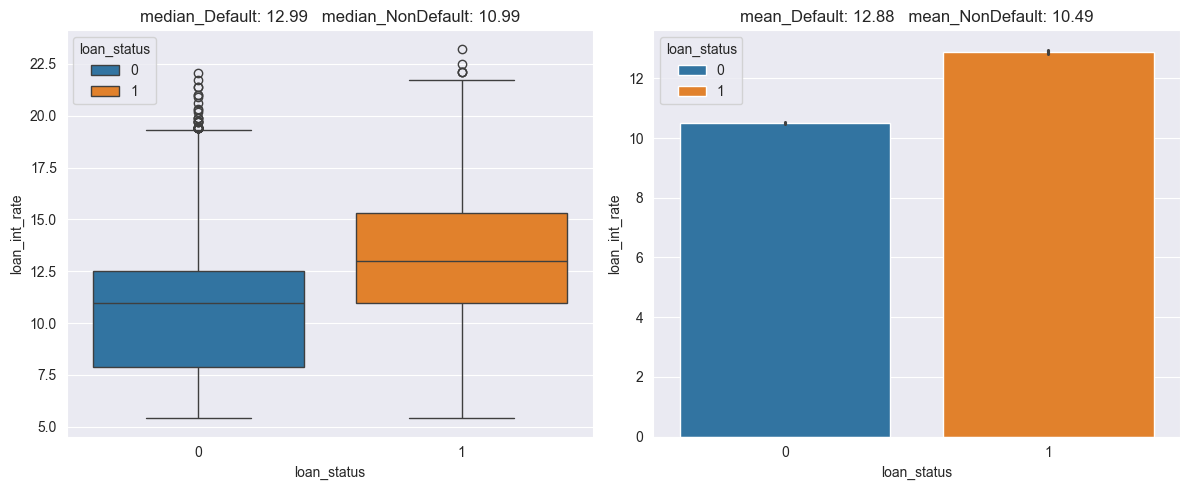

In [34]:
util.box_barPlot('loan_status','loan_int_rate')

    - observation de la moyenne des taux d'interet pour les groupe du status de defaut

In [35]:
util.qdiscret_proportion('loan_int_rate','loan_status')[0]

loan_int_rate_TRANCHE  loan_int_rate_TRANCHE  loan_status
FAIBLE                 FAIBLE                 0              0.903937
                                              1              0.096063
MOYEN                  MOYEN                  0              0.828835
                                              1              0.171165
HAUT                   HAUT                   0              0.814797
                                              1              0.185203
FORT                   FORT                   0              0.571501
                                              1              0.428499
Name: proportion, dtype: float64

        - calcule des correlations

In [36]:
stat_test.corr_cohen('loan_int_rate')

(0.8196630499761354, np.float64(0.0))

Observation:t

    - On a des proportion assez equilibre entre [ FAIBLE, MOYEN , HAUT ], le point de distinction serais donc le type de rate FORT
    - la moyen des taux d'interet lier au defaut est de 12.88 %
    -  pour les taux d'interet de type FORT on remarque un equilibre entre les groupes de status, ce qui contraste avec la tendance des Type [ FAIBLE, MOYEN , HAUT ]

    - Pour ceette distribution on peut dire qu'avec un taux d'interet eleve la probabilite de faire defaut est aussi eleve


    - Ce qu'il faut compredre c'est qu'au dela de la moyen qui est de 11% les observation ont tendance a faire defaut

    - la difference des moyenne est significative mais l'effet de taille est tres fort, cette variable a un potentiel predictive


VISUALISATION

_______

LOAN_PERCENT_INCOME

    Question:
        - pour les observation qui tombe dans [4, 20 ] determiner si les revenu sont consequent , est ce que c'est du au fait que les profile sont fragile ?
          determiner leur moyenne de revenu et les intension de pret, cela donne ses indication sur le comportement



        - pour chaque class de la part de pret quel indicateur de stabilite ?
                -  exemple: pour ceux localise en dessous de 9 % quel stabilite ?

    - Determinons si les observation avec un pourcentage de pret dans les revenu entre  [4,20] sont lier au niveaux de revenu eleve

In [37]:
# exponentiel pour une lecture simple
meanOf= math.exp(
    dataset[ (dataset['loan_percent_income'] >= 0.004 ) & (dataset['loan_percent_income'] <= 0.20) ]['log_person_income'].mean()
)
pd.Series({'MEAN_OF_[4,20]':meanOf,'GLOBAL_INCOME_MEAN': math.exp(dataset.log_person_income.mean()) })

MEAN_OF_[4,20]        62031.883744
GLOBAL_INCOME_MEAN    55458.355267
dtype: float64

In [38]:
percents_groupdf = dataset[ (dataset['loan_percent_income'] >= 0.004 ) & (dataset['loan_percent_income'] <= 0.20) ]

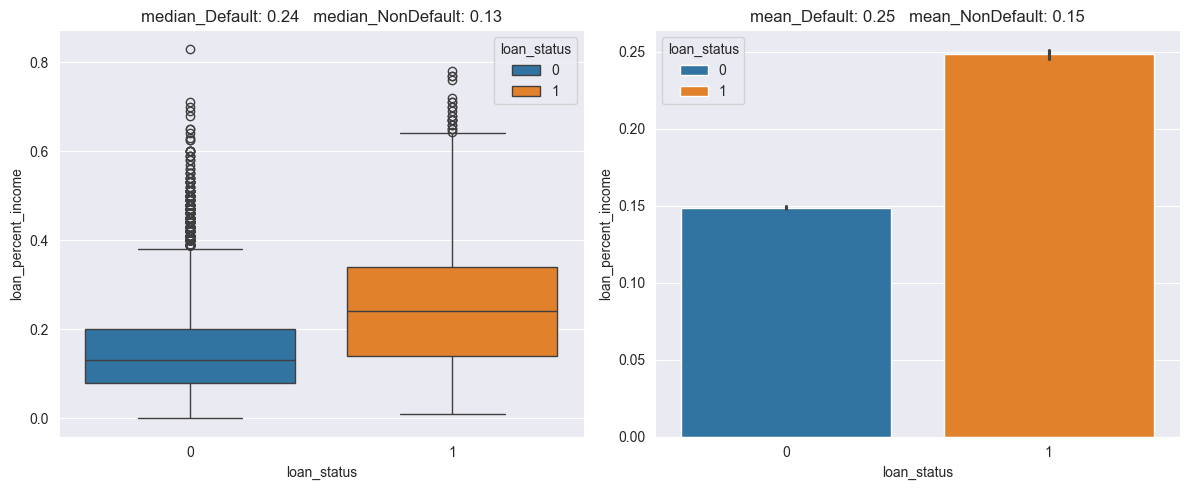

In [39]:
util.box_barPlot('loan_status','loan_percent_income')

    discretisation

In [40]:
# recupere les moyenne de revenu pour chaque tranche
get_mean = lambda  dataset, feature , type : math.exp(dataset[dataset[feature +'_TRANCHE'] == type].log_person_income.mean())

In [41]:
# discretise les pourcentage
discretise_,_ = util.qcut('loan_percent_income')

# on place les moyenne de chaque groupe dans une liste
lst =[get_mean(discretise_,'loan_percent_income',type) for type in ['FAIBLE','MOYEN','HAUT','FORT']]

<Axes: >

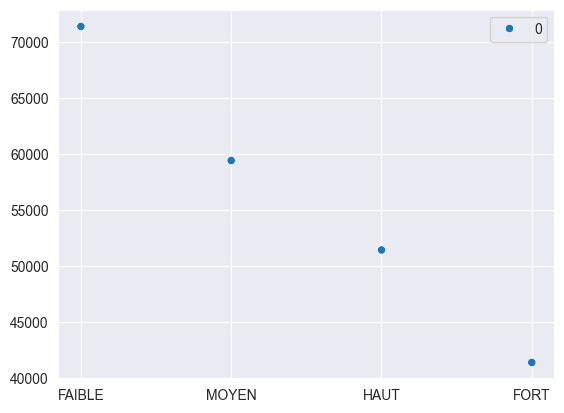

In [42]:
# observation
sns.scatterplot(pd.DataFrame(lst,index=['FAIBLE','MOYEN','HAUT','FORT']))

    - Observation des statut de defaut

    - Obs:
        - ceux qui ont des pourcentage entre [4,20] ont  tendance a avoire des revenu proche et superieure a la moyene global
        - pour ce groupe, ceux qui en moyenne atteingne 12% de part de credit dans le revnu sont suceptible de faire defaut

        - Les observations qui ont un faible pourcentage de credit dans les revenus semble avoir  une moyenne  des revenu eleve sachant que le ratio pret/revenu constitue  9%

        - en gros plus le revenu est eleve plus le ratio pret/revenu est faible

        - ceux que les donnees nous disent c'est que des lors qu'on atteint les 12 ou 15% la probabilite de faire defaut augmente

_______________

CB_PERSON_CRED_HIST_LENGTH



        Quetion:
            - ceux a qui on attribuer des credit est ce parce qu'il ont beaucoup de revenu, est ce qu'il prenne pret faible qui ne constitue qu'un petit pourcentge des revenu
            - est ce parceque ces gens ont une vie  stable ( experience de travaille ) pas de dette
            - En gros A qui on attribu le credit ?

    - est ce que ceux a qui on attribut des credit on des revenu faible ?

In [43]:
get_mean = lambda  dataset, feature , type : math.exp(dataset[dataset[feature +'_TRANCHE'] == type].log_person_income.mean())

In [44]:
discretise_,limit = util.qcut('cb_person_cred_hist_length')
lst =[get_mean(discretise_,'cb_person_cred_hist_length',type) for type in ['FAIBLE','MOYEN','HAUT','FORT']]


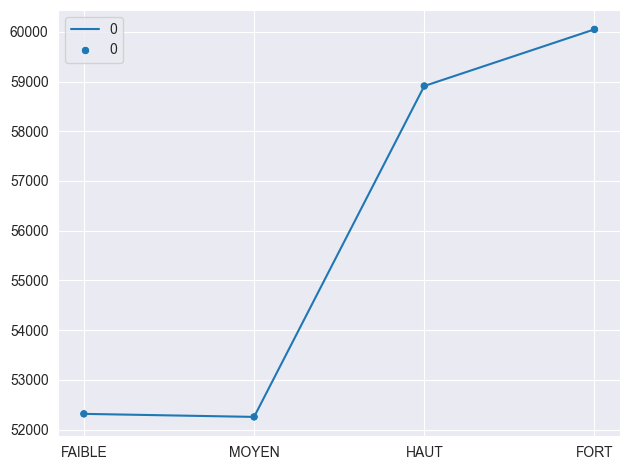

In [45]:
sns.lineplot(pd.DataFrame(lst,index=['FAIBLE','MOYEN','HAUT','FORT']))
sns.scatterplot(pd.DataFrame(lst,index=['FAIBLE','MOYEN','HAUT','FORT']))
plt.tight_layout()
plt.show()


    ceux qui ont des faible nombre de credit ont une moyen superieur a ceux qui ont un nombre moyen de credit, est ce des person jeune ?

    ont ils plus de de credit parcequ'il  ont une stabilite en terme d'experience de travaille , domicile , pas endetter ?

In [46]:
view = lambda df , type : pd.Series(
        {'MEAN_AGE'  :     math.exp(df[df['cb_person_cred_hist_length_TRANCHE'] == type]['log_person_age'].mean()),
         'EXPERIENCE':     df[df['cb_person_cred_hist_length_TRANCHE']          == type]['person_emp_length'].mean(),
         'MODE_HOME_OWN':  df[df['cb_person_cred_hist_length_TRANCHE']          == type]['person_home_ownership'].mode()[0],
         'MODE_DEFAULT' :  df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_default_on_file'].mode()[0]
         })

In [47]:
pd.DataFrame([view(discretise_,'FAIBLE'),view(discretise_,'MOYEN'),view(discretise_,'HAUT'),view(discretise_,'FORT') ], index=['FAIBLE','MOYEN','HAUT','FORT'])

,MEAN_AGE,EXPERIENCE,MODE_HOME_OWN,MODE_DEFAULT
FAIBLE,23.582888,4.047089,RENT,N
MOYEN,23.579316,3.959466,RENT,N
HAUT,29.874346,5.209378,RENT,N
FORT,34.891281,5.570286,RENT,N


    examination du taux de defaut

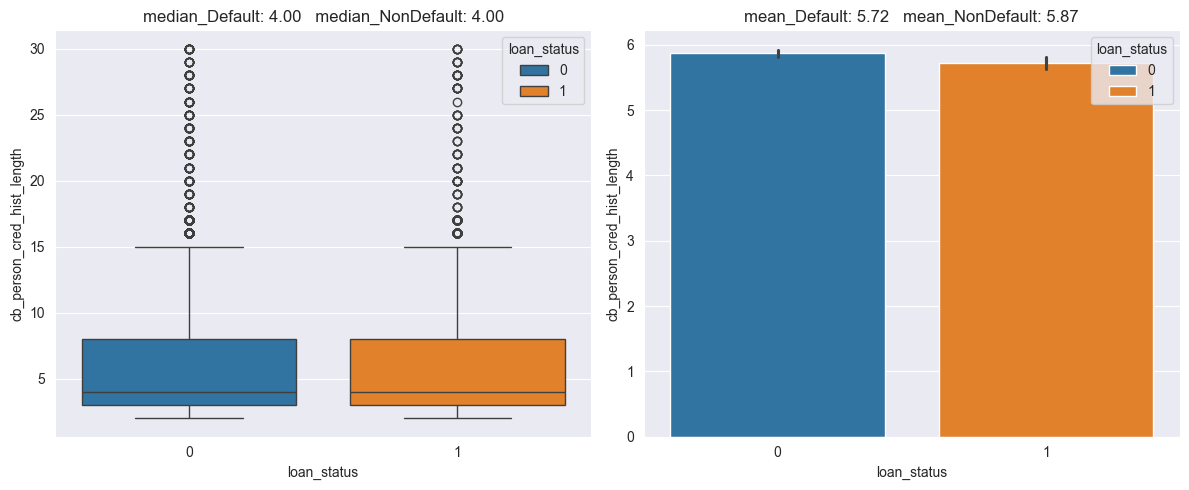

In [48]:
util.box_barPlot('loan_status', 'cb_person_cred_hist_length')

    examinons le taux de defaut dans les type , on admet 4 types  d'historique [FAIBLE,MOYEN,HAUT,FORT] en terme de nombre

In [49]:
discretise_

,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_age,log_person_income,cb_person_cred_hist_length_TRANCHE
0,OWN,5.0,EDUCATION,B,1000,11.14,0,0.100000,N,2,3.044522,9.169518,FAIBLE
1,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.570000,N,3,3.218876,9.169518,FAIBLE
2,RENT,4.0,MEDICAL,C,35000,15.23,1,0.530000,N,2,3.135494,11.089805,FAIBLE
3,RENT,8.0,MEDICAL,C,35000,14.27,1,0.643382,Y,4,3.178054,10.904119,MOYEN
4,OWN,2.0,VENTURE,A,2500,7.14,1,0.250000,N,2,3.044522,9.200290,FAIBLE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31828,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.110000,N,30,4.043051,10.878047,FORT
31829,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.150000,N,19,3.988984,11.695247,FORT
31830,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.460000,N,28,4.174387,11.238489,FORT
31831,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.100000,N,26,4.025352,11.918391,FORT


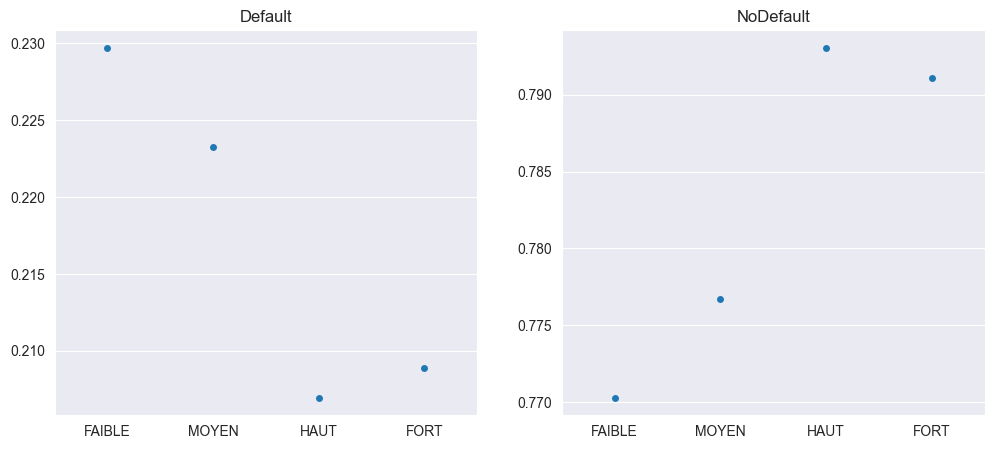

In [50]:
util.scatter_of_default_qtl('cb_person_cred_hist_length')

        quel est la moyenne de nombre de  credit dans chaque type d'historique ?

In [51]:
# ON RECUPERE CHAQUE MOYEN
discretise_ = util.qcut('cb_person_cred_hist_length')[0]
view = lambda df , type : pd.Series(
        {''+type  :     df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_cred_hist_length'].mean(),
         ''+type:       df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_cred_hist_length'].mean(),
         ''+type:       df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_cred_hist_length'].mean(),
         ''+type :      df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_cred_hist_length'].mean()
         })

In [52]:
pd.DataFrame(
    [ view(discretise_,'FAIBLE')['FAIBLE'],
      view(discretise_,'MOYEN')['MOYEN'] ,
      view(discretise_,'HAUT')['HAUT'] ,
      view(discretise_,'FORT')['FORT'] ],
    index=['FAIBLE','MOYEN','HAUT','FORT']).T


,FAIBLE,MOYEN,HAUT,FORT
0,2.499739,4.0,6.507141,12.026094


        est qu'il on deja fais defaut dans le passe ? quel est leur proportion dans le fichier default_on_file

In [53]:
view = lambda df , type : pd.Series(
        {''+type  :     df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_default_on_file'].value_counts(normalize=True),
         ''+type:       df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_default_on_file'].value_counts(normalize=True),
         ''+type:       df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_default_on_file'].value_counts(normalize=True),
         ''+type :      df[df['cb_person_cred_hist_length_TRANCHE']          == type]['cb_person_default_on_file'].value_counts(normalize=True),
         })

In [54]:
pd.DataFrame(
    [ view(discretise_, 'FAIBLE')  ['FAIBLE'],
      view(discretise_, 'MOYEN' )  ['MOYEN' ] ,
      view(discretise_, 'HAUT'  )  ['HAUT'  ] ,
      view(discretise_, 'FORT'  )  ['FORT'  ] ],
    index=['FAIBLE','MOYEN','HAUT','FORT']).T

,FAIBLE,MOYEN,HAUT,FORT
cb_person_default_on_file,,,,
N,0.822763,0.83215,0.818917,0.821268
Y,0.177237,0.16785,0.181083,0.178732


coefficient de corelation

In [55]:
stat_test.corr_cohen('cb_person_cred_hist_length')

(0.03595697347005443, np.float64(0.008020890549862223))

In [56]:
discretise_, _ = util.qdiscret_proportion('cb_person_cred_hist_length','loan_status')



Obs:

        - ceux a qui on a le plus souvent attribuer des credit ont des revenu eleve,
        - Pour repondre la question a qui on prete le plus , d'apres le scatter plot , on aura tendance a dire , on prete a ceux qui ont plus de revenu

        - le scartter plot sur la moyenne des defaut dans les type d'historique nous indique que ceux qui ont le plus de credit dans l'historique ont des moyenne
          de defaut relativement bas , c'est  un indicatuer  de confiance

        - il faut en moyenne a voir 12 nombre de credit dans l'historique pour etre dans la class FORT
        - sur la question est ce qu'il ont deja fait defaut dans le passe : en observant la table de contingence on peut voir que ceux qui ont un faible nombre de credit dans l'historique
          ont une grande proportion de non_defaut



        - en ce qui concene la correlation avec le target on vois bien que la relation est significative mais avec une taille d'effet faible ce qui veut dire
          que ce feature ne peu etre interssant que dans une combinaison

______________

LOAN_INTENT

    Question :
        - qui sont ceux qui ont une grande frequence de defaut ?
        - ceux qui parte en education quel est leur moyenne de revenu et quel moyen d'age ?

    est ce que ceux qui presente des des raison d'education ont des haut revenu ?


In [57]:
educ_income_mean = math.exp(dataset[dataset['loan_intent'] == 'EDUCATION']['log_person_income'].mean())
educ_age_mean    = math.exp(dataset[dataset['loan_intent'] == 'EDUCATION']['log_person_age'].mean())

pd.Series({'EDUC_INCOME_MEAN': educ_income_mean,'EDUC_AGE_MEAN': educ_age_mean})

EDUC_INCOME_MEAN    54892.078016
EDUC_AGE_MEAN          26.127031
dtype: float64

    Verifions les information sur les revenu , on veut localiser les revenu juger stable

In [58]:
pd.Series(math.exp(dataset['log_person_income'].mean()),index =['INCOME_MEAN'])

INCOME_MEAN    55458.355267
dtype: float64

        si on discretise les revenu en groupe on saura ou localise

In [59]:
_,limit = util.qcut('log_person_income')
[math.exp(x) for x in limit]

[3999.9999999999995,
 38400.00000000009,
 55000.00000000005,
 79049.99999999999,
 1900000.0]

        Qui sont ceux qui ont une grande frequence de defaut ?

<Axes: xlabel='loan_intent', ylabel='count'>

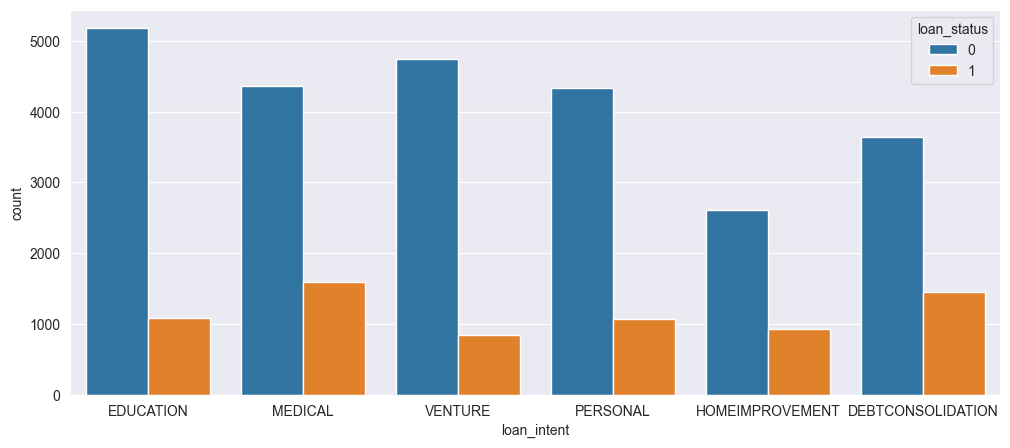

In [60]:
plt.subplots(figsize = (12,5))
sns.countplot(dataset, x = dataset['loan_intent'], hue = 'loan_status')

CORRELATION AVEC TARGET

        - recherche de signale dans la table de contingence ?

            - commencencons par une table de contingence des effectif par ligne

In [61]:
util.contingency_effLine('loan_status','loan_intent')

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE,All
loan_status,,,,,,,
0,0.114504,0.162850,0.082085,0.136871,0.136179,0.148933,0.781422
1,0.045519,0.033927,0.029184,0.049917,0.033739,0.026293,0.218578
All,0.160023,0.196777,0.111268,0.186787,0.169918,0.175227,1.000000


        - table de contingence des pourcentage par ligne

In [62]:
util.contingency_perLine('loan_status','loan_intent')

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE,All
loan_status,,,,,,,
0,0.715548,0.827586,0.737719,0.732762,0.801442,0.849946,0.781422
1,0.284452,0.172414,0.262281,0.267238,0.198558,0.150054,0.218578


Obs:


    -  On observation avec pour intention font parti groupe juge comme ayant des revenu MOYEN
    -  le countplot donne une idee sur les categorie les plus dense en terme d'observation, et degage les modalite de defaut
                - il en ressort que les observation avec des raison medicale sont en tete d'observation ayant un grand nombre de defaut
    -  la table de contigence des pourcentage confirme que les observation ayant des besoin medical ont un probabilite de defaut parmis les plus eleve 28%

# CORRELATION

        - CORRELATION ENTRE VARIABLE QUANTITATIVE

In [63]:
num_F = dataset.select_dtypes('number').drop('loan_status', axis=1)

n_corr = num_F.corr(method='pearson').round(2)


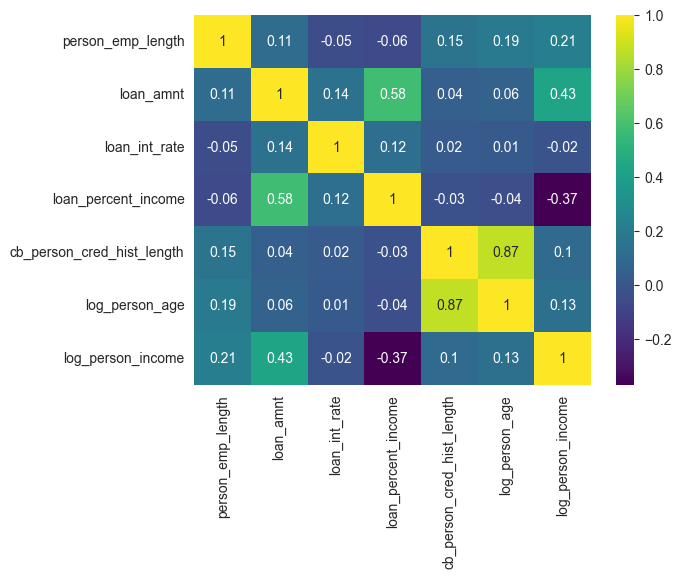

In [64]:
sns.heatmap(n_corr, cmap='viridis', annot=True)
_,limit = util.qcut('log_person_income')

        CORRELATION ENTRE VARIABLE QUALITATIVE

<Axes: >

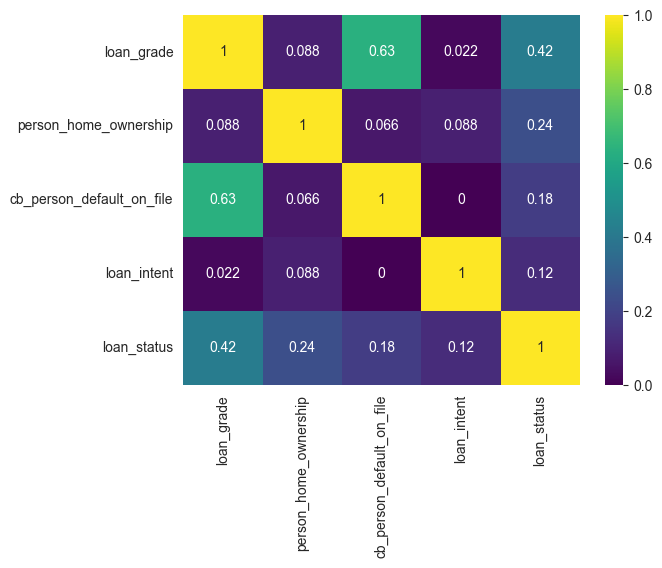

In [65]:
cat_F = dataset.select_dtypes(include='string').copy()

cat_cor = stat_test.cramer_matrix(cat_F.columns.tolist())


sns.heatmap(cat_cor, cmap='viridis', annot=True)

        CORRELATION QUANTITATIVE VS TARGET ( BISERIAL POINT )

In [66]:
res = {}

for col in num_F:
    corr, p_value = stats.pointbiserialr(dataset['loan_status'],dataset[col])
    res[col] = {'correlation': corr, 'p_value': p_value}

corr_df = pd.DataFrame(res)

corr_df

,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,log_person_age,log_person_income
correlation,-8.641340e-02,1.046931e-01,0.320852,0.385071,-0.014859,-0.024687,-0.283095
p_value,8.026964e-54,2.824524e-78,0.000000,0.000000,0.008021,0.000011,0.000000


# Filtre

    - eliminer redondance ( Pour les Quantitative ) seuil ( 0.7 - 0.8 )


In [69]:
delete = ['log_person_age']

uncorreledDf = dataset.copy()
uncorreledDf.drop(delete,inplace=True,axis=1)

In [70]:
uncorreledDf.to_csv(path_or_buf="/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/uncorreled_data.csv",sep=',',index=None)